<a href="https://colab.research.google.com/github/mahzee96/Homework_1_DACSS_DACSS_690_C/blob/main/DACSS_690C_ZEESHAN_MAHMOOD_HOMEOWORK_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Import GeoPandas to read, filter, project, and map geographic data.
import geopandas as gpd

# Import pandas to work with tables.
import pandas as pd

# Import Matplotlib to create the LISA maps.
import matplotlib.pyplot as plt

# Import ESDA to calculate Local Moran's I.
import esda

# Import Graph to create Queen and KNN spatial weights.
from libpysal.graph import Graph

In [ ]:
#Read the URL for the Peru package into the workbook.
LinkPeru="https://github.com/DACSS-CSSmeths-summer/datafiles/raw/main/PeruMaps.gpkg"
#Display the good_geom layer for our Peru geopackage.
peru=gpd.read_file(LinkPeru,layer='good_geom')
# Provide bbasic description of the dataset.
peru.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 1873 entries, 0 to 1872
Data columns (total 10 columns):
 #   Column                    Non-Null Count  Dtype   
---  ------                    --------------  -----   
 0   DEPARTAMENTO              1873 non-null   object  
 1   PROVINCIA                 1873 non-null   object  
 2   DISTRITO                  1873 non-null   object  
 3   ubigeo                    1873 non-null   object  
 4   Poblacion                 1873 non-null   int64   
 5   IDH2019                   1873 non-null   float64 
 6   Educ_sec_comp2019_pct     1873 non-null   float64 
 7   NBI2017_pct               1873 non-null   float64 
 8   Viv_sin_serv_hig2017_pct  1873 non-null   float64 
 9   geometry                  1873 non-null   geometry
dtypes: float64(4), geometry(1), int64(1), object(4)
memory usage: 146.5+ KB


The dataset includes 9 columns, and all 1873 rows have a value, containing 0 nulls. We have 4 object, 1 int64, 4 float64, and 1 gemotry datatype in our dataset. Besides the spatial units (DEPARTAMEN, PROVINCIA, DISTRITO, and Ubigeo - "Ubigeo" is a code ), we have:

Poblacion: Population (2017)
IDH2019: Human Development Index for DISTRITO (2019)
Educ_sec_comp2019_pct: Share of Population that finished High-School (2019)
NBI2017_pct: Share of Population with poverty at the household level aggregated by DISTRITO. This index ("Unsatisfied Basic Needs") uses observable living conditions rather than income alone (2017).
Viv_sin_serv_hig2017_pct: Share of housing units that have no sanitation infrastructure aggregated by DISTRITO (2017)

Take a look at the spatial properties:

In [ ]:
#This code checks the current crs number, whether the crs is projected, and sets peru as the geom_type.

peru.crs.to_epsg(),\
peru.crs.is_projected, \
set(peru.geom_type)

(4326, False, {'MultiPolygon'})

True


<Axes: >

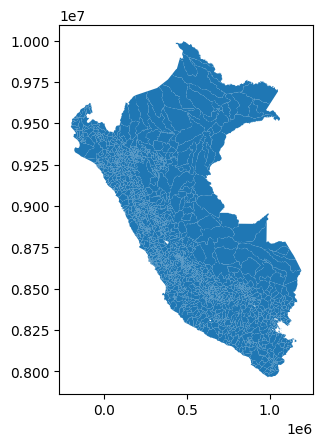

In [ ]:
# Check whether the Peru map is projected.
print(peru.crs.is_projected)

# Use CRS 5387 only if the map is not already projected.
if not peru.crs.is_projected:
    peru = peru.to_crs(5387)

# Plot the Peru map.
peru.plot()

Change DEPARTAMENTO to "Lima", as the homework instructions suggested.

---



In [ ]:
#Define the object lima as the Peru map's DEPARTAMENTO filtered  to rows that only show Lima.
lima=peru[peru['DEPARTAMENTO']=='Lima']
lima

,DEPARTAMENTO,PROVINCIA,DISTRITO,ubigeo,Poblacion,IDH2019,Educ_sec_comp2019_pct,NBI2017_pct,Viv_sin_serv_hig2017_pct,geometry
39,Lima,YAUYOS,ALIS,PE151002,1233,0.646897,69.474298,30.3,6.6,"MULTIPOLYGON (((415396.076 8647591.116, 415450..."
40,Lima,YAUYOS,AYAUCA,PE151003,2293,0.544152,43.167400,61.9,57.2,"MULTIPOLYGON (((389530.693 8626520.884, 389743..."
54,Lima,HUAURA,AMBAR,PE150802,2761,0.316448,42.060097,73.3,60.2,"MULTIPOLYGON (((243293.978 8826436.11, 243328...."
65,Lima,LIMA,ANCON,PE150102,42124,0.668889,72.117976,21.7,1.1,"MULTIPOLYGON (((281417 8715329, 281397.439 871..."
71,Lima,OYON,ANDAJES,PE150902,1058,0.488913,71.684369,36.4,28.5,"MULTIPOLYGON (((291522.945 8820149.937, 291499..."
...,...,...,...,...,...,...,...,...,...,...
1799,Lima,LIMA,VILLA MARIA DEL TRIUNFO,PE150143,473036,0.689812,73.895534,21.9,1.3,"MULTIPOLYGON (((294277.314 8649754.267, 294333..."
1804,Lima,YAUYOS,VINAC,PE151032,1906,0.353468,48.996169,57.8,45.3,"MULTIPOLYGON (((415274.705 8578168.622, 415429..."
1813,Lima,YAUYOS,VITIS,PE151033,665,0.515071,58.157218,20.1,13.6,"MULTIPOLYGON (((415484.035 8649162.757, 415430..."
1850,Lima,YAUYOS,YAUYOS,PE151001,2905,0.578646,68.601779,37.3,17.3,"MULTIPOLYGON (((406970.333 8623705.927, 406944..."


In [ ]:
#Produce the LISA MAP using the normalized neighborhood  matrix (or weights matrix) using the QUEEN criterion
#Save a column for the LISA category, rename the categories as we did in the tutorial. The new column will be "Lisa_queen"
lima_queen=Graph.build_contiguity(lima,rook=False)

In [ ]:
#Get the normalized matrix for lima_queen.
lima_queen=lima_queen.transform("r")

### IV. 2 Local

We can compute a Local Index of Spatial Association (LISA -local Moran) for each map polygon. That will help us find spatial clusters (spots) and spatial outliers:

- High-High (HH): values above average surrounded by values above average.These are also known as **hotSpot**s.
- Low-Low (LL): values below average surrounded by values below average. These are also known as **coldSpot**s.
- High-Low (HL): values above average surrounded by values below average.These are also known as **hotOutlier**s.
- Low-High (LH): values below average surrounded by values above average. These are also known as **coldOutlier**s.

It is also possible that no significant correlation is detected. Let's see those values:



a. Compute the LISAs:

In [ ]:
# Import ESDA so Local Moran's I can be calculated.

import esda

In [ ]:
# Calculate Local Moran's I using the normalized Queen weights.
lisa_queen = esda.Moran_Local(lima['Educ_sec_comp2019_pct'], lima_queen)


#### IV. 2. 1 Analysis Local Spatial Correlation quadrants

You can not get the quadrant labels from the previous plot directly into the original GDF, thus complicating further analysis and exporting of those results.

First let's recover the labels into a new column:

In [ ]:
# Save the Queen LISA category for each district.
lima['Lisa_queen'] = lisa_queen.get_cluster_labels(
    crit_value=0.05
)

/usr/local/lib/python3.12/dist-packages/geopandas/geodataframe.py:1969: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


In [ ]:
# Original category names returned by Local Moran's I.
oldLabels=['Insignificant', 'Low-Low', 'High-High', 'High-Low', 'Low-High']

# Renamed categories used in the tutorial.
newLabels = ['3 no_pattern', '4 coldSpot','2 hotSpot','1 hotOutlier' , '5 coldOutlier']

#Replace the old lables with the new labels created.
labels = dict(zip(oldLabels, newLabels))

labels

{'Insignificant': '3 no_pattern',
 'Low-Low': '4 coldSpot',
 'High-High': '2 hotSpot',
 'High-Low': '1 hotOutlier',
 'Low-High': '5 coldOutlier'}

In [ ]:
# Rename the Queen LISA categories.
lima['Lisa_queen'] = lima['Lisa_queen'].replace(labels)

In [ ]:
# Create one representative point inside each Lima district.
lima_points = lima.geometry.representative_point()

# Build a K-nearest-neighbors matrix using the eight nearest districts.
lima_knn8 = Graph.build_knn(
    lima_points,
    k=8
)

# Normalize the KNN weights using row standardization.
lima_knn8 = lima_knn8.transform("r")

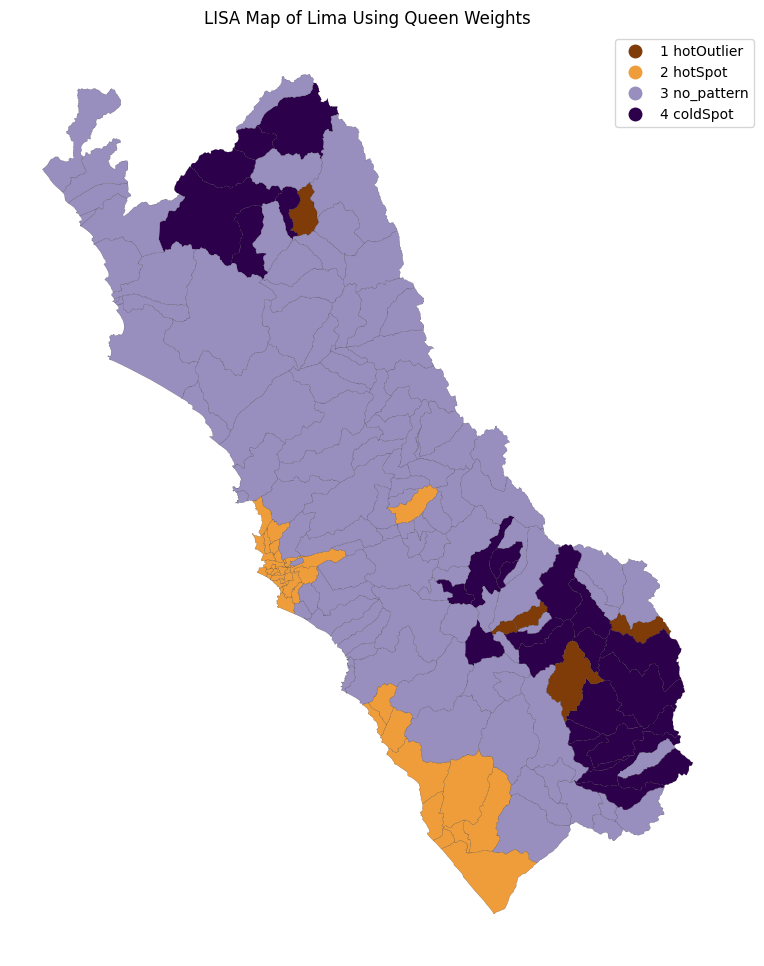

In [ ]:
# Create the five-category color palette used in the tutorial.
myColMap = plt.get_cmap("PuOr", 5)

# Produce the LISA map using the normalized Queen weights.
lima.plot(
    column="Lisa_queen",
    categorical=True,
    cmap=myColMap,
    linewidth=0.1,
    edgecolor="k",
    legend=True,
    legend_kwds={"bbox_to_anchor": (1.05, 1)},
    figsize=(12, 12)
)

# Add a descriptive title.
plt.title("LISA Map of Lima Using Queen Weights")

# Remove the map axes.
plt.axis("off")

# Display the Queen LISA map.
plt.show()

In [ ]:
# Calculate Local Moran's I using:
# 1. the secondary-education variable
# 2. the normalized KNN-8 neighborhood matrix
lisa_knn8 = esda.Moran_Local(
    lima["Educ_sec_comp2019_pct"],
    lima_knn8
)

In [ ]:
# Save the KNN-based LISA category for each district.
# The significance level is 0.05, matching the tutorial.
lima["Lisa_knn8"] = lisa_knn8.get_cluster_labels(
    crit_value=0.05
)

In [ ]:
# Rename the KNN LISA categories using the same labels
# that were used for the Queen LISA categories.
lima["Lisa_knn8"] = lima["Lisa_knn8"].replace(labels)

/usr/local/lib/python3.12/dist-packages/geopandas/geodataframe.py:1969: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


In [ ]:
# Display how many districts belong to each KNN LISA category.
lima["Lisa_knn8"].value_counts().sort_index()

,count
Lisa_knn8,
1 hotOutlier,8
2 hotSpot,47
3 no_pattern,76
4 coldSpot,39
5 coldOutlier,1


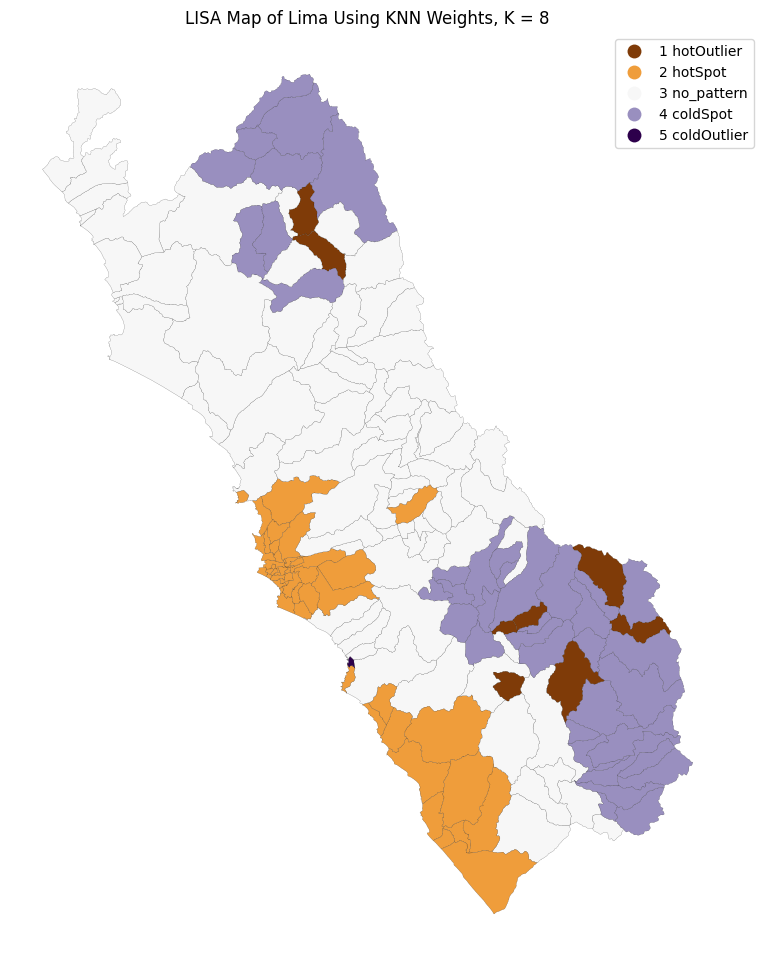

In [ ]:
import matplotlib.pyplot as plt #import matplotlib library and pyplot package.

# Define the custom colormap needed for the LISA plot.
myColMap = plt.get_cmap('PuOr', 5)

# Plot the KNN-8 LISA map.
lima.plot(
    column="Lisa_knn8",
    categorical=True,
    cmap=myColMap,
    linewidth=0.1,
    edgecolor="k",
    legend=True,
    legend_kwds={"bbox_to_anchor": (1.05, 1)},
    figsize=(12, 12)
)

# Add a title to the map.
plt.title("LISA Map of Lima Using KNN Weights, K = 8")

# Remove the coordinate axes.
plt.axis("off")

# Display the map.
plt.show()

In [ ]:
# Check whether the two LISA categories are different.
different_groups = lima['Lisa_queen'] != lima['Lisa_knn8']

# Keep only the districts with different categories.
changed_districts = lima[different_groups]

# Display only the columns needed for the report.
changed_districts[
    ['PROVINCIA', 'DISTRITO', 'Lisa_queen', 'Lisa_knn8']
]

,PROVINCIA,DISTRITO,Lisa_queen,Lisa_knn8
54,HUAURA,AMBAR,4 coldSpot,3 no_pattern
224,LIMA,CARABAYLLO,3 no_pattern,2 hotSpot
315,HUAURA,CHECRAS,3 no_pattern,1 hotOutlier
390,LIMA,CIENEGUILLA,3 no_pattern,2 hotSpot
396,CANETE,COAYLLO,3 no_pattern,2 hotSpot
450,CAJATAMBO,COPA,3 no_pattern,4 coldSpot
479,HUAROCHIRI,CUENCA,3 no_pattern,4 coldSpot
544,CAJATAMBO,GORGOR,3 no_pattern,4 coldSpot
557,YAUYOS,HONGOS,3 no_pattern,4 coldSpot
615,YAUYOS,HUANCAYA,3 no_pattern,1 hotOutlier


In [ ]:
# Display every district that changed groups.

changed_districts

,DEPARTAMENTO,PROVINCIA,DISTRITO,ubigeo,Poblacion,IDH2019,Educ_sec_comp2019_pct,NBI2017_pct,Viv_sin_serv_hig2017_pct,geometry,Lisa_queen,Lisa_knn8
54,Lima,HUAURA,AMBAR,PE150802,2761,0.316448,42.060097,73.3,60.2,"MULTIPOLYGON (((243293.978 8826436.11, 243328....",4 coldSpot,3 no_pattern
224,Lima,LIMA,CARABAYLLO,PE150106,322936,0.649869,74.114567,20.0,1.4,"MULTIPOLYGON (((303318.697 8699809.811, 303106...",3 no_pattern,2 hotSpot
315,Lima,HUAURA,CHECRAS,PE150804,1864,0.341390,71.662176,64.1,56.1,"MULTIPOLYGON (((305244.325 8791619.712, 305283...",3 no_pattern,1 hotOutlier
390,Lima,LIMA,CIENEGUILLA,PE150109,50486,0.637172,69.643266,24.7,2.3,"MULTIPOLYGON (((312481.516 8672905.162, 312524...",3 no_pattern,2 hotSpot
396,Lima,CANETE,COAYLLO,PE150506,1097,0.623068,83.024611,29.4,11.7,"MULTIPOLYGON (((363947.191 8607271.506, 363935...",3 no_pattern,2 hotSpot
450,Lima,CAJATAMBO,COPA,PE150302,803,0.153212,36.220955,83.7,73.4,"MULTIPOLYGON (((292530.914 8860325.894, 292776...",3 no_pattern,4 coldSpot
479,Lima,HUAROCHIRI,CUENCA,PE150706,397,0.313482,51.373292,38.2,32.9,"MULTIPOLYGON (((342124.472 8660101.228, 342156...",3 no_pattern,4 coldSpot
544,Lima,CAJATAMBO,GORGOR,PE150303,2774,0.277028,31.801136,59.0,40.0,"MULTIPOLYGON (((277129.582 8833757.025, 277353...",3 no_pattern,4 coldSpot
557,Lima,YAUYOS,HONGOS,PE151012,388,0.197668,16.477878,49.2,46.0,"MULTIPOLYGON (((437345.201 8594234.009, 437366...",3 no_pattern,4 coldSpot
615,Lima,YAUYOS,HUANCAYA,PE151014,1424,0.472777,81.420105,82.0,65.4,"MULTIPOLYGON (((416666.709 8666736.536, 416718...",3 no_pattern,1 hotOutlier


In [ ]:
# Count how many districts changed LISA categories.
number_changed = len(changed_districts)

# Report whether any district changed groups.
if number_changed == 0:
    print("No districts changed groups between Queen and KNN-8.")
else:
    print(
        number_changed,
        "districts changed groups between Queen and KNN-8."
    )

31 districts changed groups between Queen and KNN-8.


Some districts did not belong to the same LISA group under the two neighborhood methods. The table identifies each district and shows its Queen category and KNN-8 category. This occurs because Queen defines neighbors through shared borders or corners, while KNN assigns each district its eight nearest districts. 31 districts changed groups between Queen and KNN-8.